In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
data = {
    "email": [
        "Congratulations you won a free prize",
        "Win money now click this link",
        "Free offer claim your reward",
        "You have won a lottery prize",
        "Get free cash immediately",
        "Click here to win a free gift",
        "Limited offer claim your bonus",
        "Congratulations you are a winner",
        "Earn money from home easily",
        "Free vacation offer for you",

        "Meeting scheduled for tomorrow",
        "Please find the project report attached",
        "Can we discuss the assignment today",
        "Your interview is confirmed",
        "Please submit the document by Friday",
        "The team meeting starts at 10 AM",
        "Here are the notes from today's class",
        "Your order has been shipped",
        "Please review the attached file",
        "Let's meet tomorrow for the project",

        "URGENT win free cash now",
        "Claim your free prize today",
        "You have been selected for a reward",
        "Click now for a special offer",
        "Free money waiting for you",
        "Congratulations claim your bonus",
        "Win a free mobile phone",
        "Earn cash by clicking this link",
        "Exclusive free offer for winner",
        "Get your prize immediately",

        "The exam timetable has been released",
        "Please attend the project discussion",
        "Your application has been received",
        "The lecture will start at 9 AM",
        "Please send me the project details",
        "The report is ready for review",
        "Your appointment is confirmed",
        "The class has been postponed",
        "Please check the email attachment",
        "We will discuss the project tomorrow"
    ],

    "label": [
        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",

        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham",

        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",

        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of emails:", len(df))

display(df.head(10))

Dataset created successfully!
Number of emails: 40


,email,label
0,Congratulations you won a free prize,spam
1,Win money now click this link,spam
2,Free offer claim your reward,spam
3,You have won a lottery prize,spam
4,Get free cash immediately,spam
5,Click here to win a free gift,spam
6,Limited offer claim your bonus,spam
7,Congratulations you are a winner,spam
8,Earn money from home easily,spam
9,Free vacation offer for you,spam


Spam and Ham Distribution:
label
spam    20
ham     20
Name: count, dtype: int64


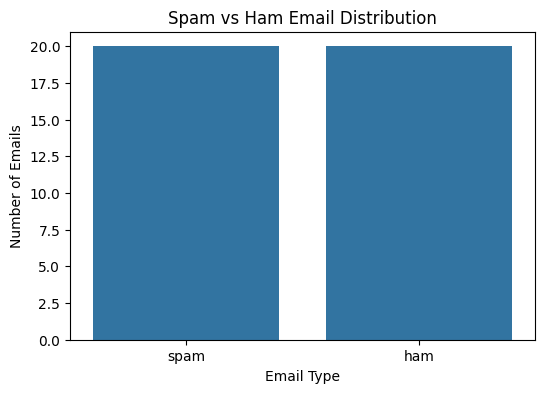

In [3]:
print("Spam and Ham Distribution:")

print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.show()

In [4]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["email"])

y = df["label"]

print("Number of features:", len(vectorizer.get_feature_names_out()))
print("Feature matrix shape:", X.shape)

Number of features: 96
Feature matrix shape: (40, 96)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 28
Testing samples: 12


In [6]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naïve Bayes model trained successfully!")

Naïve Bayes model trained successfully!


In [7]:
y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam")
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print("===== NAÏVE BAYES PERFORMANCE =====")

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

===== NAÏVE BAYES PERFORMANCE =====
Accuracy : 83.33 %
Precision: 75.0 %
Recall   : 100.0 %
F1 Score : 85.71 %


In [8]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

         ham       1.00      0.67      0.80         6
        spam       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



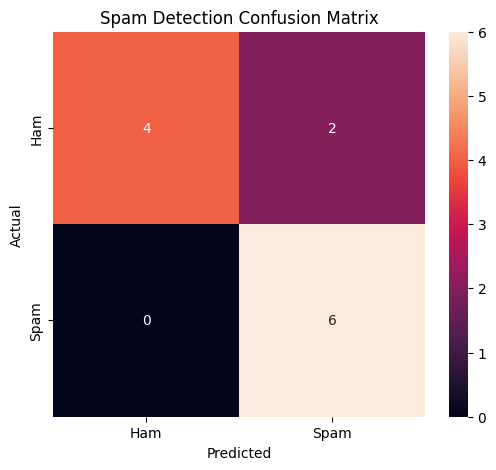

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Detection Confusion Matrix")

plt.show()

In [10]:
new_emails = [
    "Congratulations you won a free cash prize",
    "Please attend the project meeting tomorrow",
    "Click now to claim your free reward",
    "Please submit your assignment by tomorrow"
]

new_X = vectorizer.transform(new_emails)

predictions = nb_model.predict(new_X)

probabilities = nb_model.predict_proba(new_X)

print("===== NEW EMAIL PREDICTIONS =====")

for email, prediction, probability in zip(
    new_emails,
    predictions,
    probabilities
):

    print("\nEmail:", email)
    print("Prediction:", prediction)

    print(
        "Ham Probability:",
        round(probability[0] * 100, 2),
        "%"
    )

    print(
        "Spam Probability:",
        round(probability[1] * 100, 2),
        "%"
    )

===== NEW EMAIL PREDICTIONS =====

Email: Congratulations you won a free cash prize
Prediction: spam
Ham Probability: 0.03 %
Spam Probability: 99.97 %

Email: Please attend the project meeting tomorrow
Prediction: ham
Ham Probability: 99.98 %
Spam Probability: 0.02 %

Email: Click now to claim your free reward
Prediction: spam
Ham Probability: 0.02 %
Spam Probability: 99.98 %

Email: Please submit your assignment by tomorrow
Prediction: ham
Ham Probability: 94.74 %
Spam Probability: 5.26 %


In [11]:
feature_names = vectorizer.get_feature_names_out()

spam_count = np.asarray(
    X[df["label"].values == "spam"].sum(axis=0)
).flatten()

ham_count = np.asarray(
    X[df["label"].values == "ham"].sum(axis=0)
).flatten()

spam_total = spam_count.sum()
ham_total = ham_count.sum()

mle_spam_probability = spam_count / spam_total
mle_ham_probability = ham_count / ham_total

mle_table = pd.DataFrame({
    "Feature": feature_names,
    "Spam_MLE_Probability": mle_spam_probability,
    "Ham_MLE_Probability": mle_ham_probability
})

print("MLE Feature Probabilities:")
display(mle_table.head(20))

MLE Feature Probabilities:


,Feature,Spam_MLE_Probability,Ham_MLE_Probability
0,10,0.000000,0.009091
1,am,0.000000,0.018182
2,application,0.000000,0.009091
3,appointment,0.000000,0.009091
4,are,0.010101,0.009091
5,assignment,0.000000,0.009091
6,at,0.000000,0.018182
7,attached,0.000000,0.018182
8,attachment,0.000000,0.009091
9,attend,0.000000,0.009091


In [12]:
mle_table["Difference"] = abs(
    mle_table["Spam_MLE_Probability"] -
    mle_table["Ham_MLE_Probability"]
)

mle_selected = mle_table.sort_values(
    by="Difference",
    ascending=False
)

print("Top features selected using MLE:")

display(
    mle_selected.head(15)
)

Top features selected using MLE:


,Feature,Spam_MLE_Probability,Ham_MLE_Probability,Difference
80,the,0.000000,0.136364,0.136364
34,free,0.101010,0.000000,0.101010
94,you,0.060606,0.000000,0.060606
61,please,0.000000,0.054545,0.054545
58,offer,0.050505,0.000000,0.050505
64,project,0.000000,0.045455,0.045455
16,claim,0.040404,0.000000,0.040404
91,win,0.040404,0.000000,0.040404
63,prize,0.040404,0.000000,0.040404
39,has,0.000000,0.036364,0.036364


In [13]:
# Calculate how strongly each word is associated
# with spam or ham.

mdl_table = mle_table.copy()

mdl_table["Spam_Ratio"] = (
    (mdl_table["Spam_MLE_Probability"] + 1e-10) /
    (mdl_table["Ham_MLE_Probability"] + 1e-10)
)

# Distance from neutral ratio = 1
mdl_table["MDL_Information"] = abs(
    np.log2(mdl_table["Spam_Ratio"])
)

mdl_selected = mdl_table.sort_values(
    by="MDL_Information",
    ascending=False
)

print("Top features using MDL-inspired selection:")

display(
    mdl_selected[
        [
            "Feature",
            "Spam_MLE_Probability",
            "Ham_MLE_Probability",
            "MDL_Information"
        ]
    ].head(15)
)

Top features using MDL-inspired selection:


,Feature,Spam_MLE_Probability,Ham_MLE_Probability,MDL_Information
80,the,0.000000,0.136364,30.344812
34,free,0.101010,0.000000,29.911852
94,you,0.060606,0.000000,29.174887
61,please,0.000000,0.054545,29.022884
58,offer,0.050505,0.000000,28.911852
64,project,0.000000,0.045455,28.759849
16,claim,0.040404,0.000000,28.589924
91,win,0.040404,0.000000,28.589924
63,prize,0.040404,0.000000,28.589924
39,has,0.000000,0.036364,28.437921


In [14]:
print("========== MLE vs MDL ==========")

print("""
MLE:
- Estimates feature probabilities directly from training data.
- Simple and computationally efficient.
- Can use many features.
- May overfit when the dataset is small.

MDL:
- Balances model complexity and data explanation.
- Prefers informative features.
- Can reduce unnecessary features.
- Usually produces a simpler model.
""")

========== MLE vs MDL ==========

MLE:
- Estimates feature probabilities directly from training data.
- Simple and computationally efficient.
- Can use many features.
- May overfit when the dataset is small.

MDL:
- Balances model complexity and data explanation.
- Prefers informative features.
- Can reduce unnecessary features.
- Usually produces a simpler model.



In [15]:
feature_counts = [10, 20, 40, 60, 80]

accuracies = []

all_features = vectorizer.get_feature_names_out()

for n in feature_counts:

    selected_words = (
        mle_selected
        .head(min(n, len(mle_selected)))["Feature"]
        .values
    )

    selected_indices = [
        np.where(all_features == word)[0][0]
        for word in selected_words
    ]

    X_selected = X[:, selected_indices]

    Xtr, Xte, ytr, yte = train_test_split(
        X_selected,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    model = MultinomialNB()

    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    acc = accuracy_score(yte, pred)

    accuracies.append(acc)

print("Feature count:", feature_counts)
print("Accuracy:", accuracies)

Feature count: [10, 20, 40, 60, 80]
Accuracy: [0.8333333333333334, 1.0, 1.0, 1.0, 1.0]


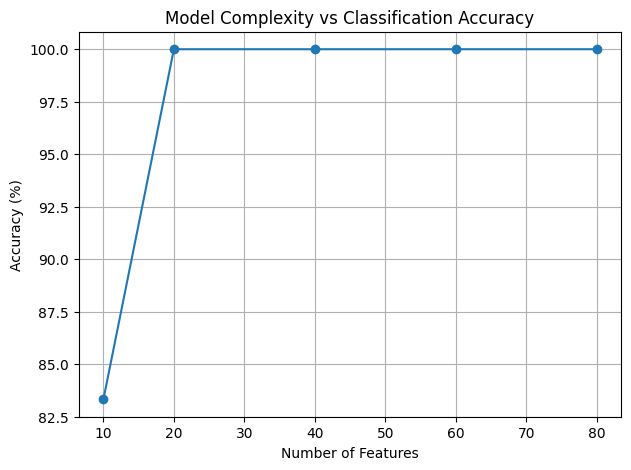

In [16]:
plt.figure(figsize=(7,5))

plt.plot(
    feature_counts,
    np.array(accuracies) * 100,
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Accuracy (%)")
plt.title("Model Complexity vs Classification Accuracy")

plt.grid(True)

plt.show()

In [17]:
sample_percentages = [30, 50, 70, 80, 90]

sample_accuracies = []

for percentage in sample_percentages:

    train_size = percentage / 100

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        random_state=42,
        stratify=y
    )

    model = MultinomialNB()

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        prediction
    )

    sample_accuracies.append(acc)

print("Training Sample Percentage:")
print(sample_percentages)

print("\nAccuracy:")
print(
    [round(x * 100, 2) for x in sample_accuracies]
)

Training Sample Percentage:
[30, 50, 70, 80, 90]

Accuracy:
[85.71, 100.0, 83.33, 100.0, 100.0]


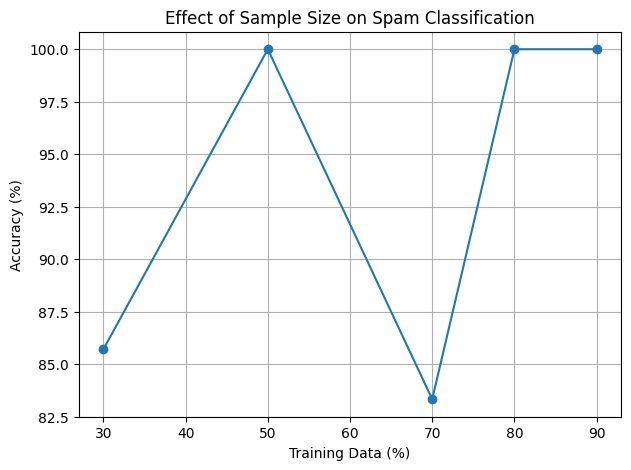

In [18]:
plt.figure(figsize=(7,5))

plt.plot(
    sample_percentages,
    np.array(sample_accuracies) * 100,
    marker="o"
)

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Sample Size on Spam Classification")

plt.grid(True)

plt.show()

In [19]:
new_email = ["Congratulations you won a free prize"]

new_vector = vectorizer.transform(new_email)

probabilities = nb_model.predict_proba(new_vector)[0]

classes = nb_model.classes_

print("===== BAYES OPTIMAL CLASSIFICATION =====")

for class_name, probability in zip(
    classes,
    probabilities
):
    print(
        f"P({class_name} | email) = "
        f"{probability * 100:.2f}%"
    )

optimal_class = classes[
    np.argmax(probabilities)
]

print("\nBayes Optimal Decision:", optimal_class)

===== BAYES OPTIMAL CLASSIFICATION =====
P(ham | email) = 0.09%
P(spam | email) = 99.91%

Bayes Optimal Decision: spam


In [20]:
print("""
==================================================
FINAL CONCLUSION
==================================================

1. Naïve Bayes provides an efficient probabilistic
   method for spam email classification.

2. The Bayes Optimal Classifier selects the class
   having the highest posterior probability.

3. Maximum Likelihood Estimation estimates feature
   probabilities directly from the training data.

4. MDL reduces model complexity by selecting useful
   features while avoiding unnecessary information.

5. Increasing the sample size generally improves
   probability estimation and classification reliability.

6. A very large hypothesis space may increase model
   complexity and overfitting, especially with small data.

7. A smaller, informative feature set can provide a
   good trade-off between accuracy, speed, and complexity.

8. In real-world spam detection, continuous retraining,
   large datasets, new spam patterns, and false positives
   must be considered.
==================================================
""")


FINAL CONCLUSION

1. Naïve Bayes provides an efficient probabilistic
   method for spam email classification.

2. The Bayes Optimal Classifier selects the class
   having the highest posterior probability.

3. Maximum Likelihood Estimation estimates feature
   probabilities directly from the training data.

4. MDL reduces model complexity by selecting useful
   features while avoiding unnecessary information.

5. Increasing the sample size generally improves
   probability estimation and classification reliability.

6. A very large hypothesis space may increase model
   complexity and overfitting, especially with small data.

7. A smaller, informative feature set can provide a
   good trade-off between accuracy, speed, and complexity.

8. In real-world spam detection, continuous retraining,
   large datasets, new spam patterns, and false positives
   must be considered.

